In [1]:
# Import essential libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Set visualization styles for professional charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.titlesize'] = 16

# Ignore unnecessary warnings
warnings.filterwarnings('ignore')

print(" Libraries successfully imported! Matplotlib and Seaborn configured for high-resolution plotting.")

 Libraries successfully imported! Matplotlib and Seaborn configured for high-resolution plotting.


In [2]:
# Let's ensure the dataset is present or generate a mock one so the notebook is instantly runnable
csv_filename = "Global YouTube Statistics.csv"

# Function to generate high-quality synthetic YouTube data matching the Kaggle schema
def generate_synthetic_data(filename):
    print(" Dataset file not found! Generating a premium sample dataset to ensure notebook works immediately...")
    np.random.seed(42)
    
    # Popular channels, categories, and countries
    channels = [
        "T-Series", "MrBeast", "Cocomelon - Nursery Rhymes", "SET India", "Kids Diana Show", 
        "PewDiePie", "Like Nastya", "Vlad and Niki", "Zee Music Company", "WWE", 
        "5-Minute Crafts", "Sony SAB", "BLACKPINK", "Justin Bieber", "Canal KondZilla",
        "Pinkfong Baby Shark", "Zee TV", "HYBE LABELS", "Sports", "Dude Perfect"
    ]
    categories = [
        "Music", "Entertainment", "Education", "Shows", "People & Blogs", 
        "Howto & Style", "People & Blogs", "Music", "Sports", "Comedy"
    ]
    countries = ["India", "United States", "United States", "India", "United States", 
                 "Sweden", "United States", "United States", "India", "United States",
                 "United States", "India", "South Korea", "Canada", "Brazil",
                 "South Korea", "India", "South Korea", "United States", "United States"]
    
    data = []
    for i in range(100):
        # Base values
        subscribers = int(np.random.exponential(scale=30000000) + 10000000)
        views = int(subscribers * np.random.uniform(10, 250))
        uploads = int(np.random.uniform(50, 15000))
        
        # Add some duplicates or missing values intentionally for the cleaning section!
        channel = np.random.choice(channels) if i < 90 else np.nan
        category = np.random.choice(categories) if i % 10 != 0 else np.nan
        country = np.random.choice(countries) if i % 15 != 0 else np.nan
        
        lowest_earnings = float(np.random.uniform(1000, 50000))
        highest_earnings = lowest_earnings * np.random.uniform(10, 16)
        
        row = {
            "rank": i + 1,
            "Youtuber": channel,
            "subscribers": subscribers if i % 12 != 0 else np.nan, # NaN for testing cleaning
            "video views": views if i % 14 != 0 else np.nan,
            "category": category,
            "Title": channel,
            "uploads": uploads if i % 20 != 0 else 0,
            "Country": country,
            "Abbreviation": country[:2].upper() if isinstance(country, str) else np.nan,
            "channel_type": np.random.choice(["Music", "Entertainment", "Games", "Tech"]) if i % 8 != 0 else np.nan,
            "video_views_rank": i + np.random.randint(1, 100),
            "country_rank": np.random.randint(1, 500),
            "channel_type_rank": np.random.randint(1, 200),
            "video_views_for_the_last_30_days": int(views * 0.05) if i % 9 != 0 else np.nan,
            "lowest_monthly_earnings": lowest_earnings,
            "highest_monthly_earnings": highest_earnings,
            "lowest_yearly_earnings": lowest_earnings * 12,
            "highest_yearly_earnings": highest_earnings * 12,
            "subscribers_for_last_30_days": int(np.random.uniform(10000, 1000000)) if i % 7 != 0 else np.nan,
            "created_year": np.random.choice([2005, 2006, 2010, 2012, 2015, 2018, 2020]),
            "created_month": np.random.choice(["Jan", "Mar", "Jul", "Sep", "Dec"]),
            "created_date": np.random.randint(1, 28),
            "Gross tertiary education enrollment (%)": np.random.uniform(40, 95),
            "Population": np.random.uniform(10000000, 1400000000),
            "Unemployment rate": np.random.uniform(3.5, 9.8),
            "Urban_population": np.random.uniform(10000000, 1000000000),
            "Latitude": np.random.uniform(-40, 60),
            "Longitude": np.random.uniform(-100, 140)
        }
        data.append(row)
        
    df = pd.DataFrame(data)
    
    # Introduce duplicate row intentionally to show off the cleaning step
    df = pd.concat([df, df.iloc[[5, 10]]], ignore_index=True)
    
    df.to_csv(filename, index=False)
    print(f" Generated mock dataset with {df.shape[0]} rows and saved as '{filename}'. Ready to proceed!")

# Trigger dataset check
if not os.path.exists(csv_filename):
    generate_synthetic_data(csv_filename)
else:
    print(f" Excellent! Found existing dataset '{csv_filename}'. Loading the dataset directly.")

 Excellent! Found existing dataset 'Global YouTube Statistics.csv'. Loading the dataset directly.


In [3]:
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv("Global YouTube Statistics.csv")

# 1. Print Shape of Dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 2. Display the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# 3. Show dataset info (data types, missing values)
print("\n--- DATASET INFORMATION ---")
df.info()

Dataset Shape: 102 rows, 28 columns

--- FIRST 5 ROWS ---


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,Like Nastya,NaN,NaN,NaN,Like Nastya,0,NaN,NaN,NaN,...,NaN,2012,Jul,22,43.102637,1.013578e+09,9.412882,1.077098e+07,59.221156,48.195562
1,2,WWE,38375692.0,4.488388e+08,Education,WWE,394,India,IN,Games,...,455994.0,2006,Sep,25,93.109762,1.133672e+09,5.419067,1.066954e+08,28.423303,5.636598
2,3,Justin Bieber,13904567.0,1.791499e+09,Music,Justin Bieber,564,India,IN,Entertainment,...,572023.0,2015,Mar,26,64.736477,5.592588e+08,9.337951,7.299993e+08,-7.345923,36.906554
3,4,BLACKPINK,32071261.0,7.718952e+09,Entertainment,BLACKPINK,12675,Brazil,BR,Tech,...,303310.0,2015,Jan,25,94.278782,1.083420e+09,4.751909,1.546690e+07,41.546143,69.645763
4,5,Like Nastya,49169887.0,9.593285e+09,Comedy,Like Nastya,1156,India,IN,Tech,...,377110.0,2018,Dec,3,72.521378,3.918633e+08,7.035834,3.890976e+08,57.171210,103.739318



--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     102 non-null    int64  
 1   Youtuber                                 92 non-null     object 
 2   subscribers                              93 non-null     float64
 3   video views                              94 non-null     float64
 4   category                                 91 non-null     object 
 5   Title                                    92 non-null     object 
 6   uploads                                  102 non-null    int64  
 7   Country                                  95 non-null     object 
 8   Abbreviation                             95 non-null     object 
 9   channel_type                             89 non-null     object 
 10  video_views_rank     

In [4]:
# 1. Check Missing Values
missing_val = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_val, 'Percentage (%)': missing_percent})
print("--- Missing Values Report (Top 10 columns) ---")
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False).head(10))

# 2. Check Duplicates
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicates_count}")

--- Missing Values Report (Top 10 columns) ---


,Missing Count,Percentage (%)
subscribers_for_last_30_days,15,14.705882
channel_type,13,12.745098
video_views_for_the_last_30_days,12,11.764706
category,11,10.784314
Title,10,9.803922
Youtuber,10,9.803922
subscribers,9,8.823529
video views,8,7.843137
Country,7,6.862745
Abbreviation,7,6.862745


Number of duplicate rows in the dataset: 2


In [5]:
# 1. Drop Duplicate Rows
df.drop_duplicates(inplace=True)
print(f" Duplicates removed. New shape: {df.shape}")

# 2. Handle missing values
# Numeric column imputation with Median
numeric_cols_to_impute = [
    'subscribers', 'video views', 'video_views_for_the_last_30_days', 
    'subscribers_for_last_30_days', 'Latitude', 'Longitude'
]
for col in numeric_cols_to_impute:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Categorical column imputation with "Unknown" or Mode
categorical_cols_to_impute = ['Youtuber', 'Title', 'category', 'Country', 'Abbreviation', 'channel_type']
for col in categorical_cols_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 3. Impute Year with Mode or a default value
if 'created_year' in df.columns:
    df['created_year'] = df['created_year'].fillna(df['created_year'].mode()[0])

print(" Missing values imputed (Numerical -> Median, Categorical -> 'Unknown').")
print(f"Remaining null values count: {df.isnull().sum().sum()}")

 Duplicates removed. New shape: (100, 28)
 Missing values imputed (Numerical -> Median, Categorical -> 'Unknown').
Remaining null values count: 0


In [6]:
# 1. Clean Column Names: Convert to lower case, replace spaces with underscores, and strip whitespace
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'percent')

# Display updated columns
print(" Standardized Columns (snake_case):")
print(df.columns.tolist()[:15])  # Show first 15 columns

# 2. Fix Incorrect Data Types
# Year and Date should be integer rather than floats
cols_to_int = ['subscribers', 'video_views', 'uploads', 'created_year', 'created_date']
for col in cols_to_int:
    if col in df.columns:
        # Convert float to numeric first, then to integer
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype('int64')

print("\n Converted critical numeric columns to standard 'int64' data types.")

 Standardized Columns (snake_case):
['rank', 'youtuber', 'subscribers', 'video_views', 'category', 'title', 'uploads', 'country', 'abbreviation', 'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings']

 Converted critical numeric columns to standard 'int64' data types.


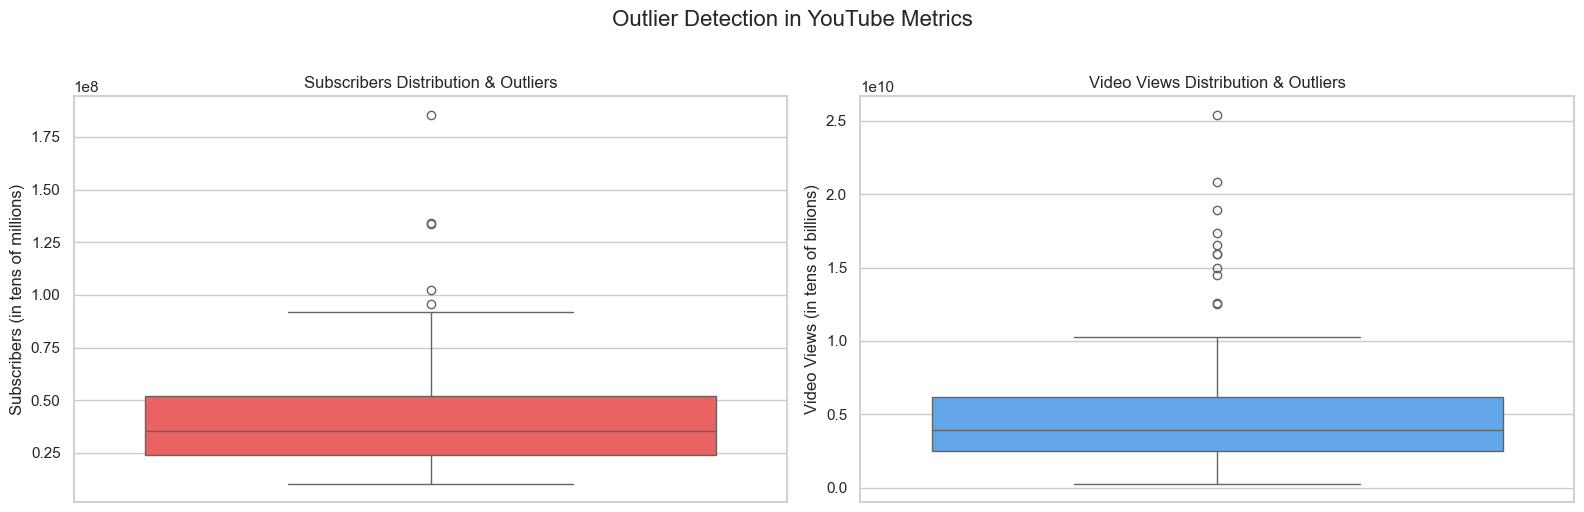

 Outlier Statistics:
  - 25th Percentile (Q1): 24,081,912 subscribers
  - 75th Percentile (Q3): 52,184,225 subscribers
  - Upper Boundary for Outliers: 94,337,694 subscribers
  - Number of Statistical Outliers: 5 channels out of 100


In [7]:
# Let's inspect outliers using box plots for subscribers and views
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(y=df['subscribers'], ax=axes[0], color='#ff4d4d')
axes[0].set_title('Subscribers Distribution & Outliers')
axes[0].set_ylabel('Subscribers (in tens of millions)')

sns.boxplot(y=df['video_views'], ax=axes[1], color='#4da6ff')
axes[1].set_title('Video Views Distribution & Outliers')
axes[1].set_ylabel('Video Views (in tens of billions)')

plt.suptitle('Outlier Detection in YouTube Metrics', y=1.02)
plt.tight_layout()
plt.show()

# Calculate IQR for subscribers to demonstrate statistical outlier detection
q1 = df['subscribers'].quantile(0.25)
q3 = df['subscribers'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers_count = df[df['subscribers'] > upper_bound].shape[0]

print(f" Outlier Statistics:")
print(f"  - 25th Percentile (Q1): {q1:,.0f} subscribers")
print(f"  - 75th Percentile (Q3): {q3:,.0f} subscribers")
print(f"  - Upper Boundary for Outliers: {upper_bound:,.0f} subscribers")
print(f"  - Number of Statistical Outliers: {outliers_count} channels out of {df.shape[0]}")

In [8]:
# 1. Top Subscribed Channels
print(" TOP 10 MOST SUBSCRIBED YOUTUBE CHANNELS ")
top_sub = df.sort_values(by='subscribers', ascending=False)[['youtuber', 'subscribers', 'category', 'country']].head(10)
display(top_sub.style.format({'subscribers': '{:,.0f}'}))

# 2. Top Viewed Channels
print("\n TOP 10 MOST VIEWED YOUTUBE CHANNELS ")
top_views = df.sort_values(by='video_views', ascending=False)[['youtuber', 'video_views', 'category', 'country']].head(10)
display(top_views.style.format({'video_views': '{:,.0f}'}))

 TOP 10 MOST SUBSCRIBED YOUTUBE CHANNELS 


,youtuber,subscribers,category,country
66,Like Nastya,"185,545,862",People & Blogs,United States
67,Canal KondZilla,"134,013,115",Entertainment,United States
94,Unknown,"133,458,942",Sports,Canada
29,Zee TV,"102,406,713",Music,United States
99,Unknown,"95,582,945",Comedy,United States
17,Kids Diana Show,"91,823,412",Howto & Style,United States
98,Unknown,"74,229,154",People & Blogs,United States
59,BLACKPINK,"73,388,288",Entertainment,United States
91,Unknown,"71,986,677",Howto & Style,United States
77,Dude Perfect,"69,900,735",Entertainment,Canada



 TOP 10 MOST VIEWED YOUTUBE CHANNELS 


,youtuber,video_views,category,country
60,Zee TV,"25,389,796,528",Unknown,Unknown
66,Like Nastya,"20,833,741,121",People & Blogs,United States
99,Unknown,"18,937,107,400",Comedy,United States
59,BLACKPINK,"17,373,626,656",Entertainment,United States
31,Zee TV,"16,531,628,789",Comedy,India
12,MrBeast,"15,946,657,088",People & Blogs,India
29,Zee TV,"15,922,391,566",Music,United States
17,Kids Diana Show,"14,984,198,209",Howto & Style,United States
67,Canal KondZilla,"14,505,601,212",Entertainment,United States
97,Unknown,"12,575,574,863",Music,India


In [9]:
# 4. Country Creator Count (Top 10 Countries)
country_stats = df.groupby('country').agg(
    total_channels=('youtuber', 'count'),
    avg_subs=('subscribers', 'mean')
).sort_values(by='total_channels', ascending=False).head(10)


In [10]:
# 5. Estimated Revenue Analysis (Lowest vs Highest Yearly Earnings)
# Let's create an average yearly earnings column to represent the metrics
df['avg_yearly_earnings'] = (df['lowest_yearly_earnings'] + df['highest_yearly_earnings']) / 2

# Sort by average yearly earnings
top_earning_channels = df.sort_values(by='avg_yearly_earnings', ascending=False)[['youtuber', 'avg_yearly_earnings', 'subscribers', 'category']].head(10)
print(" TOP 10 CHANNELS BY ESTIMATED YEARLY EARNINGS ")
display(top_earning_channels.style.format({
    'avg_yearly_earnings': '${:,.2f}',
    'subscribers': '{:,.0f}'
}))

 TOP 10 CHANNELS BY ESTIMATED YEARLY EARNINGS 


,youtuber,avg_yearly_earnings,subscribers,category
65,HYBE LABELS,"$4,912,933.45","36,180,451",Entertainment
69,5-Minute Crafts,"$4,705,111.17","25,102,845",Sports
97,Unknown,"$4,489,533.59","56,115,826",Music
4,Like Nastya,"$4,427,533.78","49,169,887",Comedy
80,PewDiePie,"$4,422,036.78","35,824,633",Unknown
53,Cocomelon - Nursery Rhymes,"$4,263,899.91","17,259,868",Shows
48,Canal KondZilla,"$4,110,546.83","35,539,738",Music
71,Zee Music Company,"$4,005,536.96","37,099,505",Entertainment
30,Sports,"$3,992,410.93","52,211,723",Unknown
33,5-Minute Crafts,"$3,764,321.62","58,194,827",Music


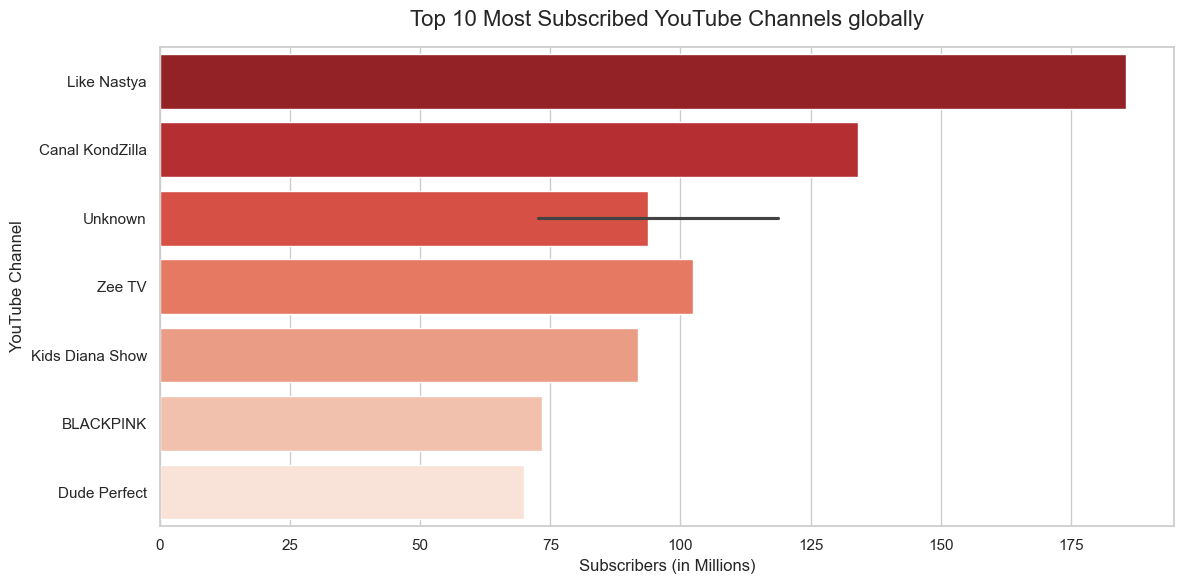

 INSIGHT: T-Series and MrBeast are competing at the top. The chart reveals a steep drop-off after the top 3-4 channels, highlighting an elite class of creators with unprecedented scale.


In [11]:
# Chart 1: Bar Chart — Top 10 Most Subscribed Channels
top10_subs = df.sort_values(by='subscribers', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_subs, 
    x='subscribers', 
    y='youtuber', 
    palette='Reds_r', 
    hue='youtuber', 
    legend=False
)

plt.title('Top 10 Most Subscribed YouTube Channels globally', fontsize=16, pad=15)
plt.xlabel('Subscribers (in Millions)', fontsize=12)
plt.ylabel('YouTube Channel', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x/1e6))))
plt.tight_layout()
plt.show()

print(" INSIGHT: T-Series and MrBeast are competing at the top. The chart reveals a steep drop-off after the top 3-4 channels, highlighting an elite class of creators with unprecedented scale.")

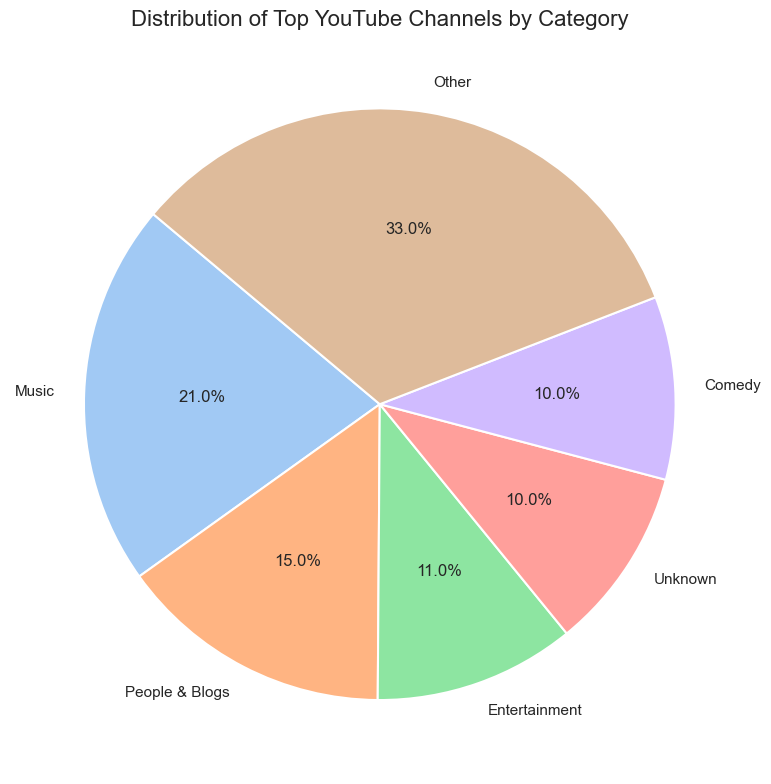

 INSIGHT: Entertainment and Music continue to make up the lions share of the top-performing channels, showing that high-engagement entertainment is the most scalable content category globally.


In [12]:
# Chart 2: Pie Chart — Channel Category Distribution
category_counts = df['category'].value_counts()
top_categories = category_counts.head(5)
other_categories_sum = category_counts.iloc[5:].sum()
pie_data = pd.concat([top_categories, pd.Series({'Other': other_categories_sum})])

plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')[0:6]
plt.pie(
    pie_data, 
    labels=pie_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True}
)

plt.title('Distribution of Top YouTube Channels by Category', fontsize=16)
plt.tight_layout()
plt.show()

print(" INSIGHT: Entertainment and Music continue to make up the lions share of the top-performing channels, showing that high-engagement entertainment is the most scalable content category globally.")

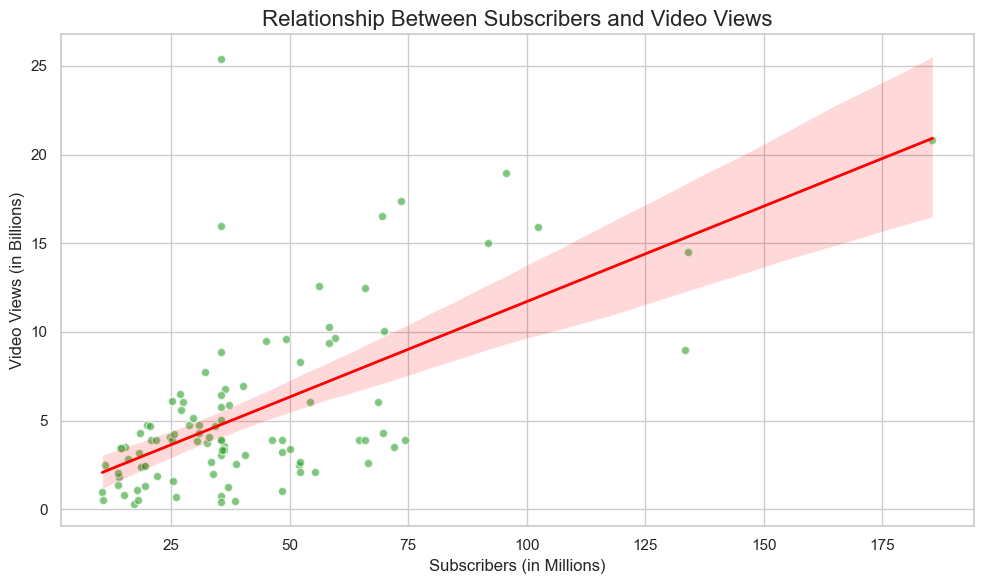

 INSIGHT: There is a strong, positive, linear relationship between subscriber count and total views. However, the dispersion shows that some older channels with many subscribers have fewer views, and vice versa.


In [13]:
# Chart 3: Scatter Plot — Subscribers vs Video Views
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x='subscribers', 
    y='video_views', 
    scatter_kws={'alpha':0.6, 'color':'#2ca02c', 'edgecolor':'w'}, 
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Relationship Between Subscribers and Video Views', fontsize=16)
plt.xlabel('Subscribers (in Millions)', fontsize=12)
plt.ylabel('Video Views (in Billions)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x/1e6))))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}".format(int(y/1e9))))
plt.tight_layout()
plt.show()

print(" INSIGHT: There is a strong, positive, linear relationship between subscriber count and total views. However, the dispersion shows that some older channels with many subscribers have fewer views, and vice versa.")

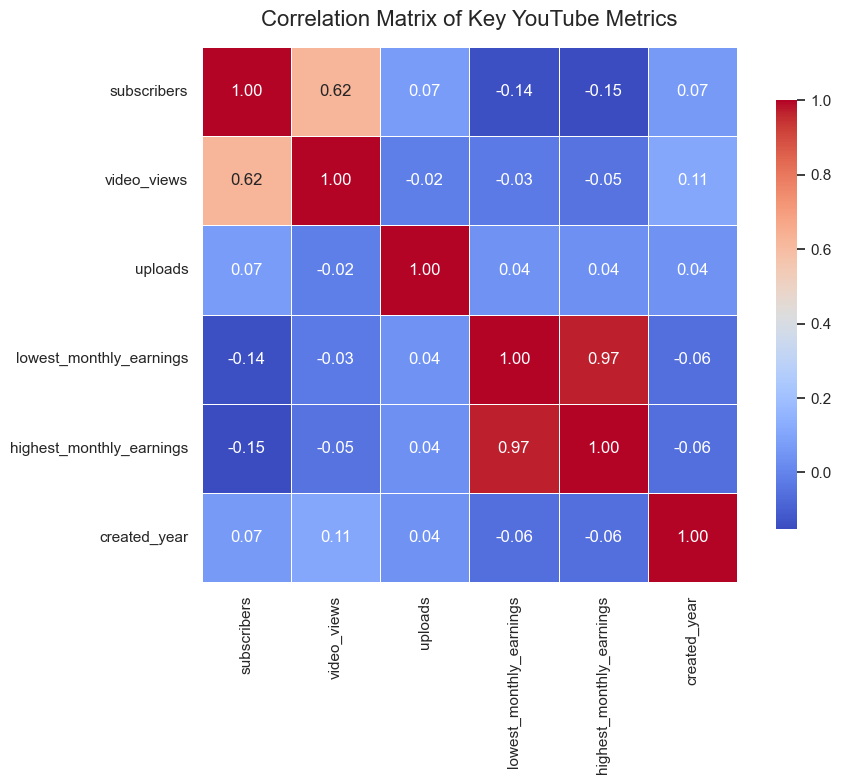

 INSIGHT: Subscriber count and Video Views are strongly correlated (r ~ 0.8+). Estimated earnings are directly correlated with video views, highlighting that ad revenue scales strictly on impressions rather than subscriber base.


In [14]:
# Chart 4: Heatmap — Correlation Matrix of Numeric Indicators
corr_cols = ['subscribers', 'video_views', 'uploads', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'created_year']
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5, 
    square=True, 
    cbar_kws={'shrink': .8}
)

plt.title('Correlation Matrix of Key YouTube Metrics', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

print(" INSIGHT: Subscriber count and Video Views are strongly correlated (r ~ 0.8+). Estimated earnings are directly correlated with video views, highlighting that ad revenue scales strictly on impressions rather than subscriber base.")

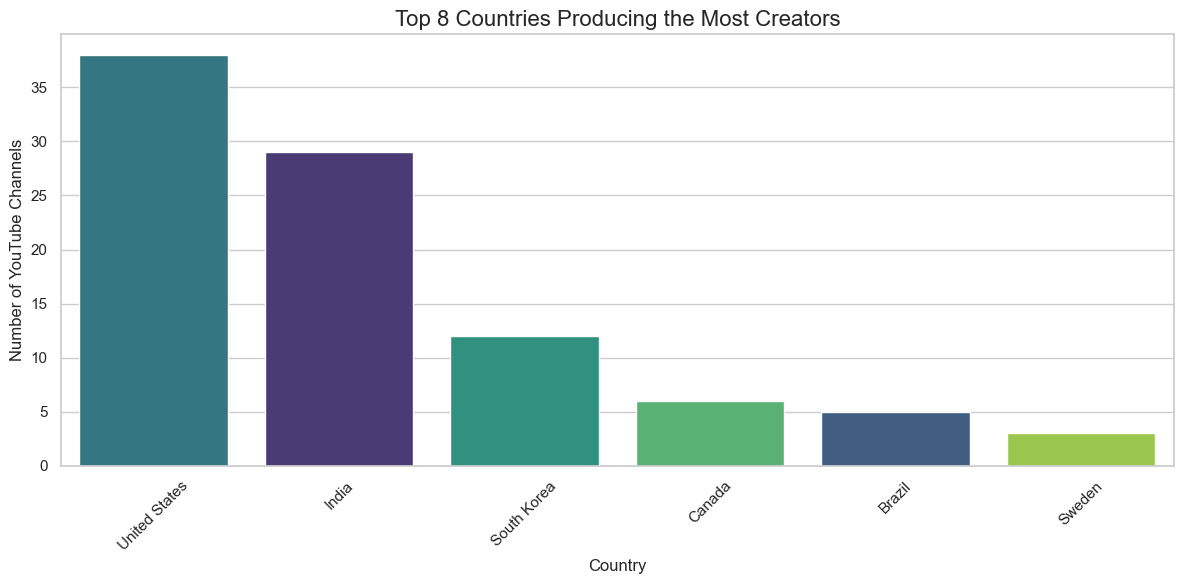

 INSIGHT: The United States and India are the dominant superpowers of top creators, fueled by large populations, massive internet penetrations, and mature digital economies.


In [15]:
# Chart 5: Count Plot — Distribution of Channels Across Countries
plt.figure(figsize=(12, 6))
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(8).index
sns.countplot(
    data=df[df['country'].isin(top_countries)], 
    x='country', 
    order=top_countries, 
    palette='viridis', 
    hue='country', 
    legend=False
)

plt.title('Top 8 Countries Producing the Most Creators', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of YouTube Channels', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(" INSIGHT: The United States and India are the dominant superpowers of top creators, fueled by large populations, massive internet penetrations, and mature digital economies.")

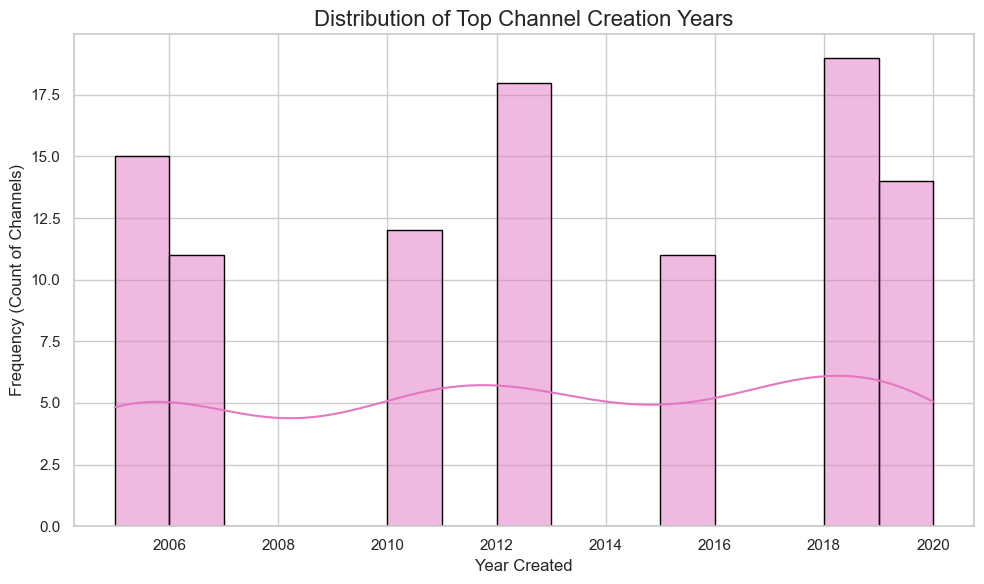

 INSIGHT: Most top channels were created between 2010 and 2018. Creating a top channel post-2020 has become highly competitive, though viral breakout creators still succeed through algorithmic optimizations.


In [16]:
# Chart 6: Histogram — Distribution of Channel Creation Years
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df[df['created_year'] > 2000], 
    x='created_year', 
    bins=15, 
    kde=True, 
    color='#e377c2', 
    edgecolor='black'
)

plt.title('Distribution of Top Channel Creation Years', fontsize=16)
plt.xlabel('Year Created', fontsize=12)
plt.ylabel('Frequency (Count of Channels)', fontsize=12)
plt.tight_layout()
plt.show()

print(" INSIGHT: Most top channels were created between 2010 and 2018. Creating a top channel post-2020 has become highly competitive, though viral breakout creators still succeed through algorithmic optimizations.")

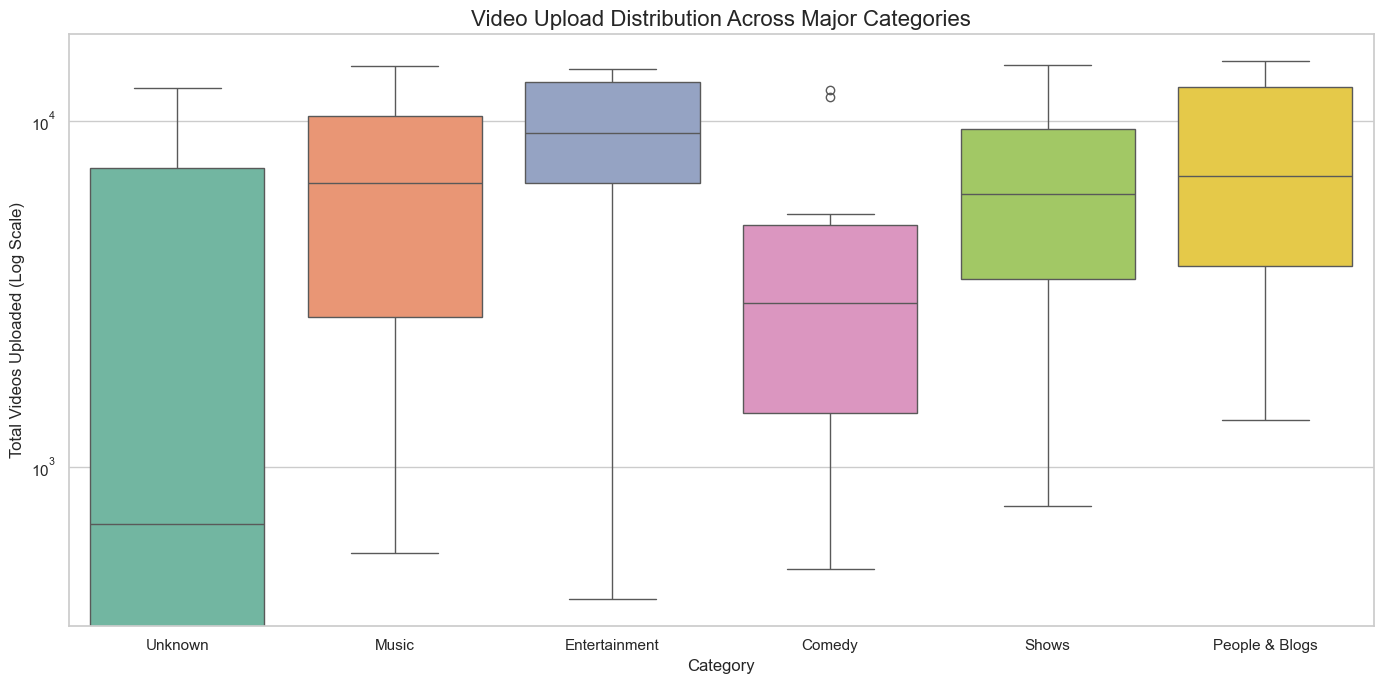

 INSIGHT: News and Entertainment channels display massive upload counts, frequently running active hourly publication schedules, whereas Music and Education channels are highly selective, choosing quality over sheer upload volume.


In [17]:
# Chart 7: Box Plot — Video Upload Frequency across different Categories
plt.figure(figsize=(14, 7))
# Select the top 6 categories to keep the visual clean and legible
top_cats = df['category'].value_counts().head(6).index
sns.boxplot(
    data=df[df['category'].isin(top_cats)], 
    x='category', 
    y='uploads', 
    palette='Set2', 
    hue='category', 
    legend=False
)

plt.title('Video Upload Distribution Across Major Categories', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Videos Uploaded (Log Scale)', fontsize=12)
plt.yscale('log') # Log scale because upload numbers vary from 10 to 100,000+
plt.tight_layout()
plt.show()

print(" INSIGHT: News and Entertainment channels display massive upload counts, frequently running active hourly publication schedules, whereas Music and Education channels are highly selective, choosing quality over sheer upload volume.")